In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils import class_weight
import numpy as np
import time
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [2]:
 

# List all physical devices
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available!")
    print("GPU devices:", gpus)
else:
    print("GPU is NOT available. Using CPU.")


GPU is available!
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Before augmentation 

Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Class Weights: {0: np.float64(0.8388645552560647), 1: np.float64(0.6129369768586903), 2: np.float64(2.259301270417423), 3: np.float64(1.3627531472359058)}


I0000 00:00:1772660007.461051    1423 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:10:00.0, compute capability: 8.6


Epoch 1/30


I0000 00:00:1772660029.286868    2811 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


312/312 ━━━━━━━━━━━━━━━━━━━━ 102s 264ms/step - accuracy: 0.5981 - loss: 1.1004 - val_accuracy: 0.4990 - val_loss: 5.5956 - learning_rate: 1.0000e-04
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 59s 187ms/step - accuracy: 0.9421 - loss: 0.1701 - val_accuracy: 0.5649 - val_loss: 1.6106 - learning_rate: 1.0000e-04
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 60s 192ms/step - accuracy: 0.9908 - loss: 0.0394 - val_accuracy: 0.7499 - val_loss: 0.7338 - learning_rate: 1.0000e-04
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 58s 185ms/step - accuracy: 0.9731 - loss: 0.0872 - val_accuracy: 0.6277 - val_loss: 0.9263 - learning_rate: 1.0000e-04
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 58s 187ms/step - accuracy: 0.9969 - loss: 0.0194 - val_accuracy: 0.8838 - val_loss: 0.3239 - learning_rate: 1.0000e-04
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 58s 187ms/step - accuracy: 0.9987 - loss: 0.0108 - val_accuracy: 0.7366 - val_loss: 0.8092 - learning_rate: 1.0000e-04
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 58s 185ms/step -

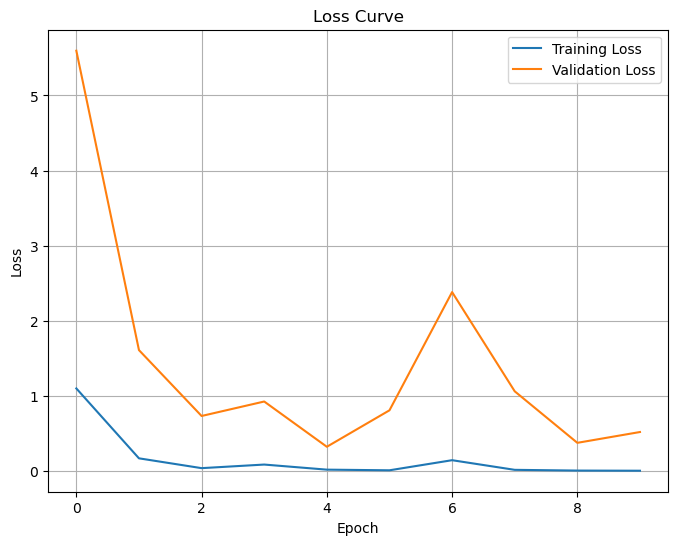

78/78 ━━━━━━━━━━━━━━━━━━━━ 14s 164ms/step


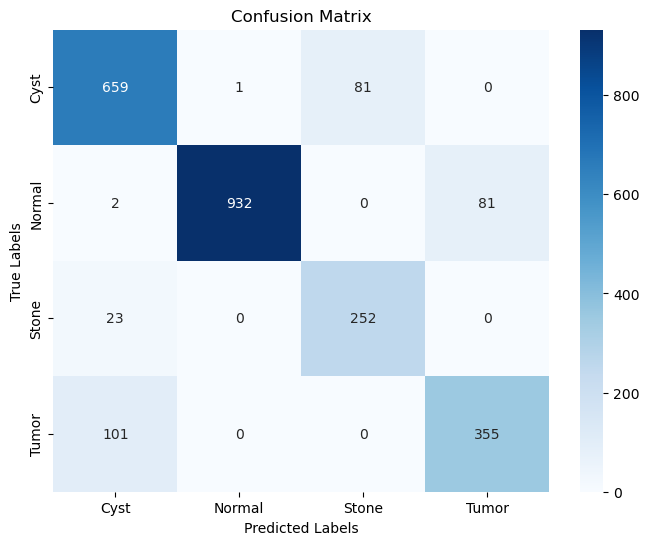

Training Time: 629.09 seconds
Testing Time: 14.11 seconds
Confusion Matrix:
 [[659   1  81   0]
 [  2 932   0  81]
 [ 23   0 252   0]
 [101   0   0 355]]
Classification Report:
               precision    recall  f1-score   support

        Cyst       0.84      0.89      0.86       741
      Normal       1.00      0.92      0.96      1015
       Stone       0.76      0.92      0.83       275
       Tumor       0.81      0.78      0.80       456

    accuracy                           0.88      2487
   macro avg       0.85      0.88      0.86      2487
weighted avg       0.89      0.88      0.89      2487

Overall Accuracy: 0.8838
Accuracy for class 'Cyst': 0.8893
Accuracy for class 'Normal': 0.9182
Accuracy for class 'Stone': 0.9164
Accuracy for class 'Tumor': 0.7785


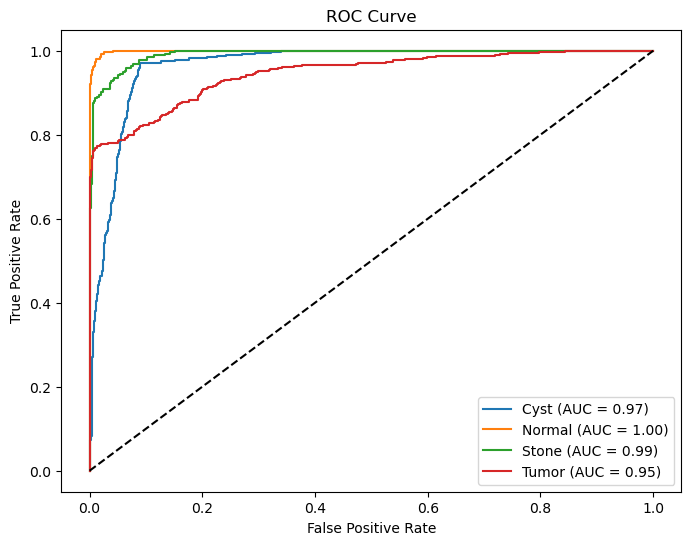

Overall Accuracy: 88.38%
Precision: 85.23%
Recall: 87.56%
F1-Score: 86.14%


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 30
DATASET_PATH = "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
 
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
y_train = train_generator.classes

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


base_model.trainable = True

for layer in base_model.layers[:-6]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_train_time = time.time()
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks

)

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

training_time = time.time() - start_train_time

start_test_time = time.time()
val_generator.reset()
y_pred_prob = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes

testing_time = time.time() - start_test_time
class_names = list(val_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys()))
accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"Training Time: {training_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)
print(f"Overall Accuracy: {accuracy:.4f}")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(val_generator.class_indices.keys()):
    print(f"Accuracy for class '{class_name}': {class_accuracy[i]:.4f}")
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(val_generator.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


accuracy = np.sum(y_pred_classes == y_true) / len(y_true)


precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

## After augmentation

Found 9310 images belonging to 4 classes.
Found 1874 images belonging to 4 classes.
Found 1262 images belonging to 4 classes.
Class Weights: {0: np.float64(0.8348278335724534), 1: np.float64(0.6129839346852779), 2: np.float64(2.2885939036381515), 3: np.float64(1.3627049180327868)}
Epoch 1/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 117s 379ms/step - accuracy: 0.3845 - loss: 1.7695 - val_accuracy: 0.1873 - val_loss: 9.7535 - learning_rate: 1.0000e-04
Epoch 2/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 102s 351ms/step - accuracy: 0.5379 - loss: 1.3698 - val_accuracy: 0.1206 - val_loss: 9.4166 - learning_rate: 1.0000e-04
Epoch 3/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 111s 382ms/step - accuracy: 0.6580 - loss: 0.9683 - val_accuracy: 0.5427 - val_loss: 2.6211 - learning_rate: 1.0000e-04
Epoch 4/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 112s 384ms/step - accuracy: 0.8029 - loss: 0.5453 - val_accuracy: 0.5480 - val_loss: 1.7559 - learning_rate: 1.0000e-04
Epoch 5/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 104s 358ms/step - accuracy: 0.8890 - l

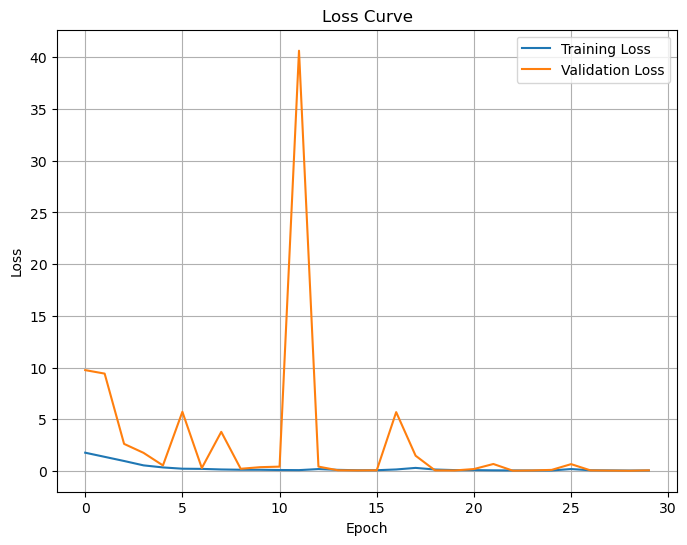

40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step


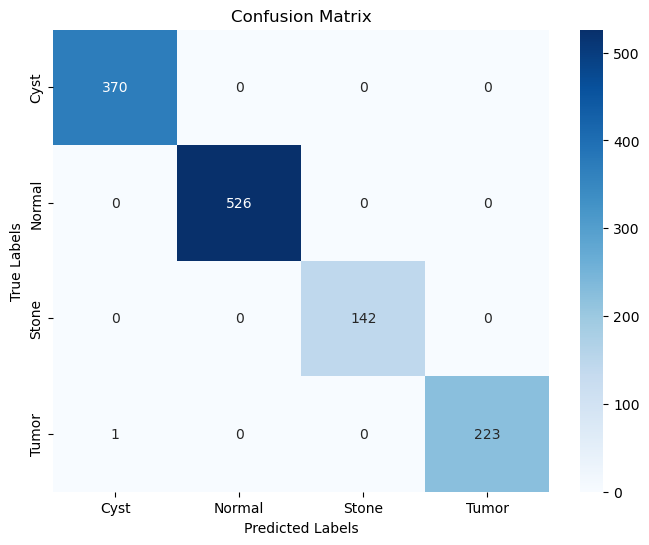

Training Time: 3146.32 seconds
Testing Time: 9.31 seconds
Confusion Matrix:
 [[370   0   0   0]
 [  0 526   0   0]
 [  0   0 142   0]
 [  1   0   0 223]]
Classification Report:
               precision    recall  f1-score   support

        Cyst       1.00      1.00      1.00       370
      Normal       1.00      1.00      1.00       526
       Stone       1.00      1.00      1.00       142
       Tumor       1.00      1.00      1.00       224

    accuracy                           1.00      1262
   macro avg       1.00      1.00      1.00      1262
weighted avg       1.00      1.00      1.00      1262

Overall Accuracy: 0.9992
Accuracy for class 'Cyst': 1.0000
Accuracy for class 'Normal': 1.0000
Accuracy for class 'Stone': 1.0000
Accuracy for class 'Tumor': 0.9955


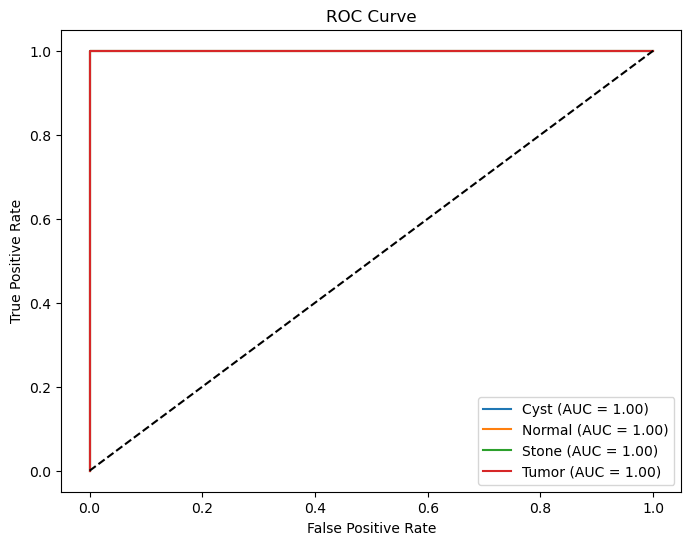

Overall Accuracy: 99.92%
Precision: 99.93%
Recall: 99.89%
F1-Score: 99.91%


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 30
DATASET_PATH = "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
test_path= "split_dataset/test"
train_path= "split_dataset/train"
val_path= "split_dataset/val"
SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)


datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,         
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

test_generator = val_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
y_train = train_generator.classes

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False 
for layer in base_model.layers[-8:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu',kernel_regularizer=l2(0.0001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu',kernel_regularizer=l2(0.0001))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_train_time = time.time()
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
]
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks

)

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

training_time = time.time() - start_train_time

start_test_time = time.time()
test_generator.reset()
y_pred_prob = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

testing_time = time.time() - start_test_time
class_names = list(test_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_true, y_pred_classes, target_names=list(test_generator.class_indices.keys()))
accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"Training Time: {training_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)
print(f"Overall Accuracy: {accuracy:.4f}")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(test_generator.class_indices.keys()):
    print(f"Accuracy for class '{class_name}': {class_accuracy[i]:.4f}")
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(test_generator.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

accuracy = np.sum(y_pred_classes == y_true) / len(y_true)

precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

In [5]:
model.save("kidney_vgg_model.keras")
model.save("kidney_vgg_model.h5")
